<a href="https://colab.research.google.com/github/KumudRathi/ASSIGNMENT-1-/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement**
Develop a Deep Neural Network (DNN) model to predict whether a student will receive college admission based on academic performance, extracurricular activities, family background, and interview performance.

**Objective of the Project**
Predict college admission status.
Improve prediction accuracy using Deep Learning.
Identify important factors affecting admissions.

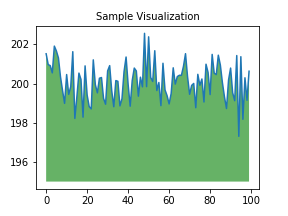

In [ ]:
#importing packages
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving genz_college_admission_prediction.csv to genz_college_admission_prediction.csv


In [ ]:
df = pd.read_csv("genz_college_admission_prediction.csv")

In [ ]:
df.head()

,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,2,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1


In [ ]:
print("Shape :",df.shape)

Shape : (1000000, 20)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   student_id             1000000 non-null  int64  
 1   age                    1000000 non-null  int64  
 2   gender                 1000000 non-null  object 
 3   state                  1000000 non-null  object 
 4   family_income          1000000 non-null  int64  
 5   high_school_gpa        1000000 non-null  float64
 6   sat_score              1000000 non-null  int64  
 7   act_score              1000000 non-null  int64  
 8   attendance_rate        1000000 non-null  float64
 9   ap_courses             1000000 non-null  int64  
 10  extracurricular_count  1000000 non-null  int64  
 11  volunteer_hours        1000000 non-null  int64  
 12  leadership_positions   1000000 non-null  int64  
 13  coding_projects        1000000 non-null  int64  
 14  social_media_hours 

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
state,0
family_income,0
high_school_gpa,0
sat_score,0
act_score,0
attendance_rate,0
ap_courses,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df = df.drop_duplicates()

print(df.shape)

(1000000, 20)


In [ ]:
df.drop(columns=["student_id"],inplace=True)

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

numerical_columns = df.select_dtypes(exclude="object").columns

print(categorical_columns)
print(numerical_columns)

Index(['gender', 'state'], dtype='object')
Index(['age', 'family_income', 'high_school_gpa', 'sat_score', 'act_score',
       'attendance_rate', 'ap_courses', 'extracurricular_count',
       'volunteer_hours', 'leadership_positions', 'coding_projects',
       'social_media_hours', 'online_certifications', 'essay_score',
       'recommendation_score', 'interview_score', 'admission_status'],
      dtype='object')


In [ ]:
encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
df.head()

,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,22,1,6,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,19,1,8,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,20,1,6,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,22,1,3,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,18,1,1,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1


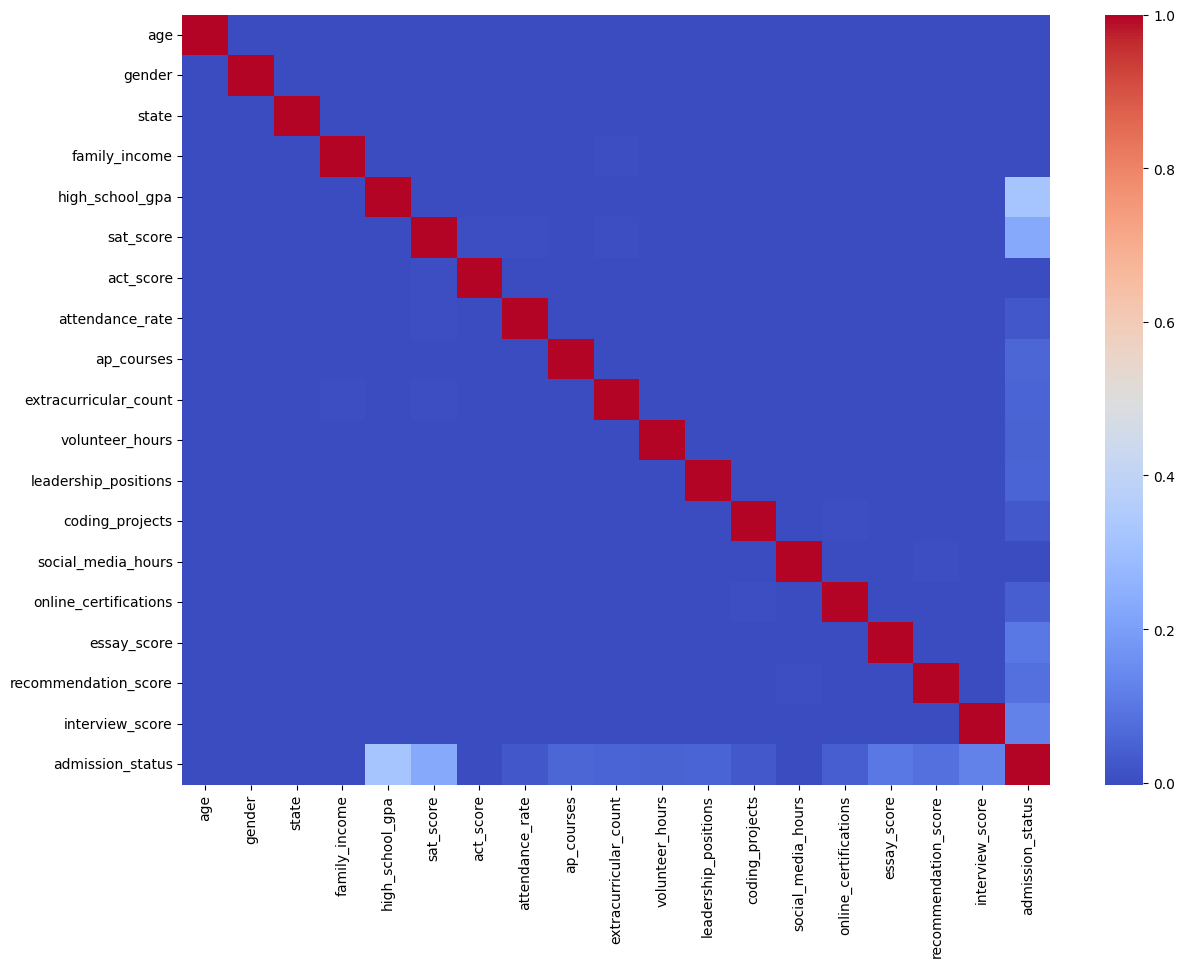

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [ ]:
X = df.drop("admission_status",axis=1)

y = df["admission_status"]

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train=torch.tensor(X_train,dtype=torch.float32)

X_test=torch.tensor(X_test,dtype=torch.float32)

y_train=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

y_test=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [ ]:
train_dataset = TensorDataset(X_train,y_train)

test_dataset = TensorDataset(X_test,y_test)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [ ]:
class DNN(nn.Module):

    def __init__(self,input_size):

        super(DNN,self).__init__()

        self.model=nn.Sequential(

            nn.Linear(input_size,128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64,32),

            nn.ReLU(),

            nn.Linear(32,1),

            nn.Sigmoid()

        )

    def forward(self,x):

        return self.model(x)

In [ ]:
model=DNN(X_train.shape[1])

print(model)

DNN(
  (model): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [ ]:
criterion = nn.BCELoss()

In [ ]:
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [ ]:
epochs=20

losses=[]

for epoch in range(epochs):

    epoch_loss=0

    for X_batch,y_batch in train_loader:

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss+=loss.item()

    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs} Loss={epoch_loss:.4f}")

Epoch 1/20 Loss=3177.6053
Epoch 2/20 Loss=3129.1422
Epoch 3/20 Loss=3124.1413
Epoch 4/20 Loss=3120.5423
Epoch 5/20 Loss=3119.2387
Epoch 6/20 Loss=3117.8522
Epoch 7/20 Loss=3115.4544
Epoch 8/20 Loss=3116.3436
Epoch 9/20 Loss=3114.3964
Epoch 10/20 Loss=3114.9794
Epoch 11/20 Loss=3115.1595
Epoch 12/20 Loss=3114.5688
Epoch 13/20 Loss=3114.5996
Epoch 14/20 Loss=3113.8194
Epoch 15/20 Loss=3112.3157
Epoch 16/20 Loss=3112.7235
Epoch 17/20 Loss=3113.0111
Epoch 18/20 Loss=3112.3787
Epoch 19/20 Loss=3110.3252
Epoch 20/20 Loss=3110.9165


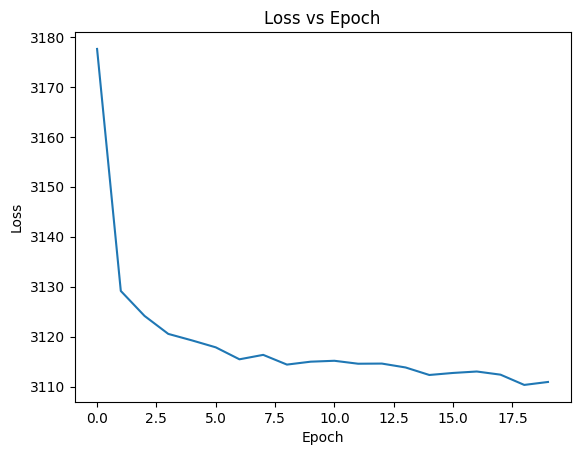

In [ ]:
plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.show()

In [ ]:
with torch.no_grad():

    outputs=model(X_test)

    predictions=(outputs>0.5).float()

In [ ]:
accuracy=accuracy_score(y_test,predictions)

print("Accuracy :",accuracy)

Accuracy : 0.8969


In [ ]:
cm=confusion_matrix(y_test,predictions)

print(cm)

[[  6096  17612]
 [  3008 173284]]


In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

         0.0       0.67      0.26      0.37     23708
         1.0       0.91      0.98      0.94    176292

    accuracy                           0.90    200000
   macro avg       0.79      0.62      0.66    200000
weighted avg       0.88      0.90      0.88    200000



In [ ]:
for name,param in model.named_parameters():

    print(name)

    print(param.data)

model.0.weight
tensor([[-0.0247, -0.0580,  0.0842,  ...,  0.2978,  0.2932,  0.4132],
        [-0.4901,  0.2089, -0.4075,  ...,  0.1469,  0.5873,  0.2159],
        [-0.2137, -0.1832,  0.0576,  ...,  0.4240,  0.4849,  0.5235],
        ...,
        [-0.2316,  0.2668,  0.0153,  ...,  0.3349,  0.2859,  0.2127],
        [-0.1730, -0.0525, -0.1676,  ..., -0.3267, -0.2836, -0.5549],
        [-0.0664, -0.0733,  0.2063,  ..., -0.2761, -0.3866, -0.3673]])
model.0.bias
tensor([ 0.8811, -1.0120,  1.0167,  0.8201, -0.6832,  0.1642, -1.5830,  0.9363,
        -1.3488, -1.4154, -2.1450,  1.2000, -0.1066, -0.0062, -1.6933,  0.8579,
        -0.8622, -0.1944,  1.0945, -0.0405,  0.9375, -1.6459,  0.0870,  1.1479,
        -0.0927, -1.0887, -1.5047, -0.8882, -1.5036, -1.3056,  1.0462,  0.5722,
         1.0227,  0.4710, -1.3592, -1.2240, -1.4847,  1.0143, -1.5990, -0.3005,
         1.0687,  0.2487, -1.4015,  0.9027,  0.7821,  0.0102,  0.3407,  1.0999,
        -0.0677,  1.0047, -1.6736, -0.9911, -1.5988,  0.54

In [ ]:
torch.save(model.state_dict(),"AdmissionModel.pth")

In [ ]:
model.load_state_dict(torch.load("AdmissionModel.pth"))

model.eval()

DNN(
  (model): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)